In [2]:
import pandas as pd
import numpy as np 

# Importations pour la construction du modèle
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import Lambda

# Importation pour la transformation sur les images
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomTranslation

# Importation pour utiliser un modèle pre entrainé
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from keras.optimizers import Adam

# Importation de l'utilitaire image_dataset_from_directory de Keras
from keras.utils import image_dataset_from_directory

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Importation pour les visualisations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, precision_score, recall_score
from metrics import MacroMetricsCallback

from sklearn.utils.class_weight import compute_class_weight

#from models.gradcam import GradCAM
#from models.gradcam import show_gradcam

#import random

print("Opération terminée")

Opération terminée


1. Chargement des images

In [3]:
chemin="/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_split"

train_ds = image_dataset_from_directory(
    directory=chemin+"/train_augmented/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=True,
   color_mode='grayscale' 
)

test_ds = image_dataset_from_directory(
    directory=chemin+"/test/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
   color_mode='grayscale'
    
)

val_ds = image_dataset_from_directory(
    directory=chemin+"/validation/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
    color_mode='grayscale'
    
)


Found 33336 files belonging to 4 classes.
Found 2084 files belonging to 4 classes.
Found 2083 files belonging to 4 classes.


2026-07-31 16:47:09.827766: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-07-31 16:47:09.827803: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-31 16:47:09.827806: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1785509229.827816  283877 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1785509229.827837  283877 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
print(train_ds.class_names)
print(val_ds.class_names)
print(test_ds.class_names)

for X_batch, y_batch in train_ds.take(1):
    print("Images :", X_batch.shape)
    print("Labels :", y_batch.shape)

['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Images : (32, 224, 224, 1)
Labels : (32,)


2026-07-31 16:47:12.596419: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [5]:
#Prétraitement des images pour la compatibilité avec le modèle EfficienNet
train_ds=train_ds.map(lambda x,y: (preprocess_input(x),y))
val_ds=val_ds.map(lambda x,y: (preprocess_input(x),y))
tes_ds=test_ds.map(lambda x,y: (preprocess_input(x),y))

In [6]:
for X_batch, y_batch in train_ds.take(1):
    print("Images :", X_batch.shape)
    print("Labels :", y_batch.shape)

Images : (32, 224, 224, 1)
Labels : (32,)


2026-07-31 16:47:15.603216: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2. Visualisation du jeu de données

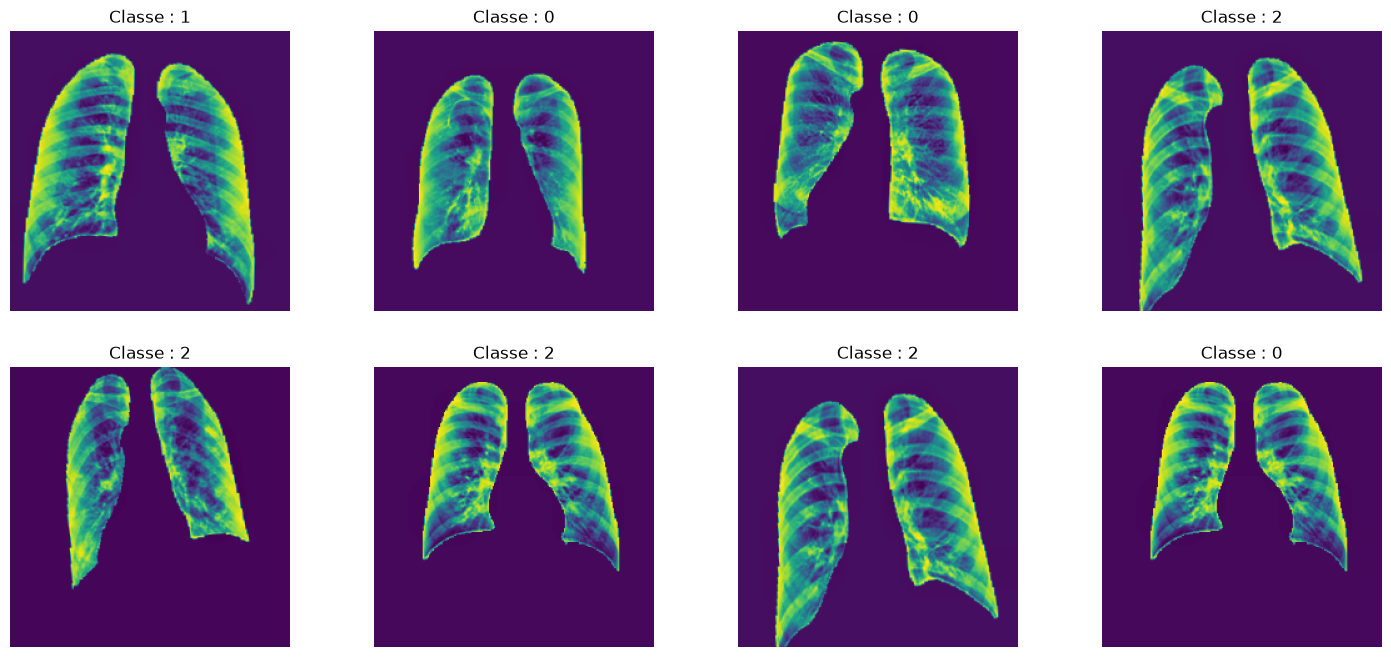

In [7]:
number_of_image=8

fig=plt.figure (figsize=(18,8))

for images, label in train_ds.take(1):
    for i in range(number_of_image):
        plt.subplot(2,4,i+1)
        indice=np.random.randint(len(label))
        plt.imshow(images[indice].numpy().astype("uint8"))
        plt.axis("off")
        plt.title(f"Classe : {label[i].numpy()}")


plt.show()

3. Chargement du modèle

In [8]:
#Choix du device
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
base_model=EfficientNetB0(weights="imagenet", include_top=False)

#Gel des couches

base_model.trainable = False

base_model

<Functional name=efficientnetb0, built=True>

In [10]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer[0][0] │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, None,      │          7 │ rescaling[0][0]   │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, None,      │          0 │ normalization[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [12]:
inputs=Input(shape=(224, 224, 1), name="Input")

x=base_model(inputs)

x=GlobalAveragePooling2D()(x)
x=Dropout(0.3)(x)
x=Dense(units=128, activation="relu")(x)
x=Dropout(0.3)(x)
outputs=Dense(units=4, activation="softmax", name="output_layer")(x)

model=Model(inputs=inputs, outputs=outputs)

In [13]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

4. Création de callbacks et d'un early stopping

In [14]:
early_stopping=EarlyStopping(monitor="val_loss",
                             patience=5,
                             min_delta=0.01,
                             mode="min",
                             verbose=1)

reduce_learning_rate=ReduceLROnPlateau(monitor="val_loss",
                           factor=0.1,
                           patience=3,
                           cooldown=4,
                           min_delta=0.01)

In [15]:
#Création d'une fonction pour suivre le f1-score à chaque epoch
from metrics import MacroMetricsCallback

macro_metrics = MacroMetricsCallback(train_ds, val_ds)
    

5. Compilation et entraînement du modèle

In [16]:
optimizer=Adam(1e-4)

In [17]:
#Compilation du modèle

model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [18]:
#Entraînement du modèle

model_history=model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=[reduce_learning_rate, early_stopping, macro_metrics])

Epoch 1/30


/opt/anaconda3/envs/Liora/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-07-31 16:47:53.234473: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.6804 - loss: 0.8032

2026-07-31 16:58:49.370573: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Train F1 : 0.7511 | Val F1 : 0.7349
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 680s 647ms/step - accuracy: 0.6804 - loss: 0.8032 - val_accuracy: 0.7897 - val_loss: 0.5509 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7511 - val_f1_macro: 0.7349
Epoch 2/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.7392 - loss: 0.6641
Train F1 : 0.7591 | Val F1 : 0.7509
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 665s 639ms/step - accuracy: 0.7392 - loss: 0.6641 - val_accuracy: 0.7988 - val_loss: 0.5258 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7591 - val_f1_macro: 0.7509
Epoch 3/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.7564 - loss: 0.6295

2026-07-31 17:20:55.126475: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Train F1 : 0.7769 | Val F1 : 0.7687
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 660s 633ms/step - accuracy: 0.7564 - loss: 0.6295 - val_accuracy: 0.8099 - val_loss: 0.5009 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7769 - val_f1_macro: 0.7687
Epoch 4/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.7685 - loss: 0.5981
Train F1 : 0.7775 | Val F1 : 0.7775
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 656s 630ms/step - accuracy: 0.7685 - loss: 0.5981 - val_accuracy: 0.8152 - val_loss: 0.4954 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7775 - val_f1_macro: 0.7775
Epoch 5/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.7738 - loss: 0.5824
Train F1 : 0.7915 | Val F1 : 0.7893
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 646s 620ms/step - accuracy: 0.7738 - loss: 0.5824 - val_accuracy: 0.8185 - val_loss: 0.4804 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7915 - val_f1_macro: 0.7893
Epoch 6/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.7754 - loss: 0.5734
Train F1 : 0.7921 | Val 

2026-07-31 18:03:24.836172: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Train F1 : 0.7986 | Val F1 : 0.7930
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 618s 594ms/step - accuracy: 0.7816 - loss: 0.5624 - val_accuracy: 0.8205 - val_loss: 0.4702 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7986 - val_f1_macro: 0.7930
Epoch 8/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.7855 - loss: 0.5552
Train F1 : 0.8021 | Val F1 : 0.7939
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 663s 637ms/step - accuracy: 0.7855 - loss: 0.5552 - val_accuracy: 0.8209 - val_loss: 0.4659 - learning_rate: 1.0000e-04 - train_f1_macro: 0.8021 - val_f1_macro: 0.7939
Epoch 9/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.7858 - loss: 0.5535
Train F1 : 0.8044 | Val F1 : 0.7967
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 626s 601ms/step - accuracy: 0.7858 - loss: 0.5535 - val_accuracy: 0.8233 - val_loss: 0.4640 - learning_rate: 1.0000e-04 - train_f1_macro: 0.8044 - val_f1_macro: 0.7967
Epoch 10/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.7862 - loss: 0.5482
Train F1 : 0.8050 | Val

In [19]:
model.save("cnn_EfficientNet_2.keras")
model.save_weights("cnn_EfficientNet_2.weights.h5")
print("modèle et poids sauvegardés")

modèle et poids sauvegardés


6. Évaluation du modèle

In [20]:
train_acc=model_history.history["accuracy"]
val_acc=model_history.history["val_accuracy"]

train_loss=model_history.history["loss"]
val_loss=model_history.history["val_loss"]

train_f1=model_history.history["train_f1_macro"]
val_f1=model_history.history["val_f1_macro"]

nb_epochs=len(train_acc)
print(nb_epochs)

12


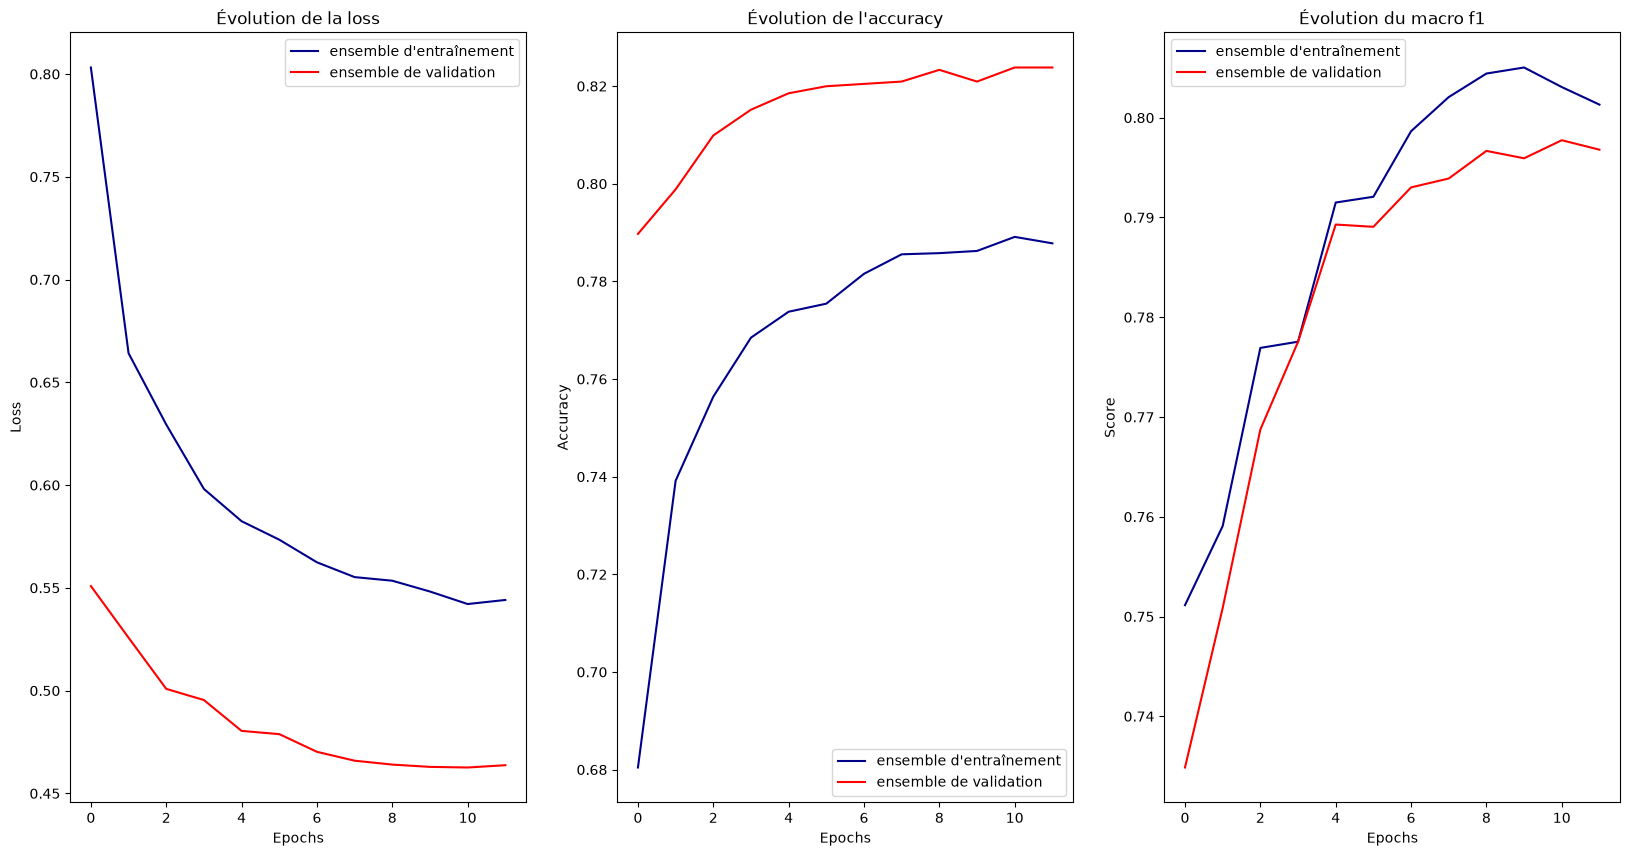

In [21]:
fig=plt.figure(figsize=(20,10))

plt.subplot(1,3,1)

plt.plot(np.arange(nb_epochs), train_loss, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_loss, color="red", label=["ensemble de validation"])

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.title("Évolution de la loss")


plt.subplot(1,3,2)

plt.plot(np.arange(nb_epochs), train_acc, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_acc, color="red", label=["ensemble de validation"])

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.title("Évolution de l'accuracy")

plt.subplot(1,3,3)

plt.plot(np.arange(nb_epochs), train_f1, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_f1, color="red", label=["ensemble de validation"])

plt.xlabel("Epochs")
plt.ylabel("Score")

plt.legend()

plt.title("Évolution du macro f1")

plt.show()

In [29]:
import pickle

with open("history_EfficientNet_2.pkl", "wb") as f:
    pickle.dump(model_history.history, f)

In [22]:
y_pred = model.predict(test_ds)
y_pred_class = y_pred.argmax(axis=1)

66/66 ━━━━━━━━━━━━━━━━━━━━ 24s 308ms/step


In [23]:
y_test_class = np.concatenate([labels for images,labels in test_ds] ,axis=0)
print(y_test_class)

[0 0 0 ... 3 3 3]


In [24]:
print(classification_report(y_test_class, y_pred_class))

              precision    recall  f1-score   support

           0       0.78      0.55      0.65       337
           1       0.82      0.79      0.81       599
           2       0.84      0.95      0.89      1014
           3       0.96      0.87      0.91       134

    accuracy                           0.83      2084
   macro avg       0.85      0.79      0.81      2084
weighted avg       0.83      0.83      0.83      2084



[[186  66  85   0]
 [ 40 475  84   0]
 [ 12  37 960   5]
 [  0   2  15 117]]


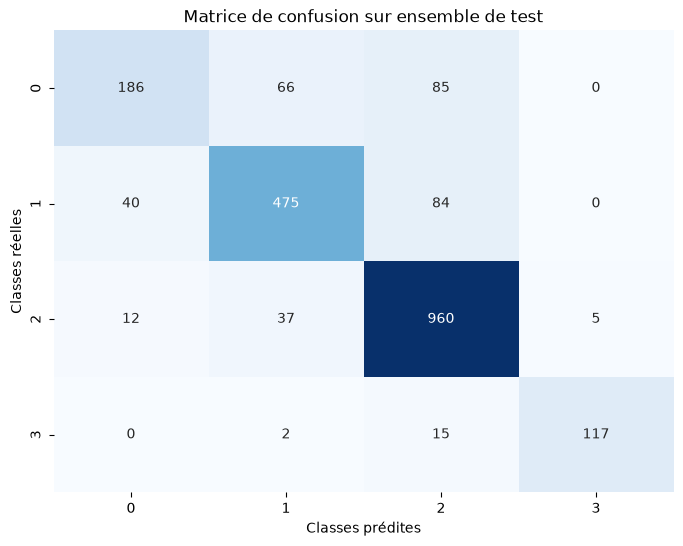

In [25]:
conf_matrix = confusion_matrix(y_test_class, y_pred_class)
    
print (conf_matrix)

plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de test")
sns.heatmap(conf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel("Classes réelles")
plt.xlabel("Classes prédites")
plt.show()

np.save("CM_EfficientNet.npy", conf_matrix)

7. Fine tuning

In [26]:
#Degel des couches inférieures : On ne dégel que le dernier bloc de convolution (block7a)
for i, layer in enumerate(base_model.layers):
    if layer.name.startswith('block7'):
            break
    freeze_from = i
for layer in model.layers[freeze_from:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [27]:
base_model.trainable = True

for layer in base_model.layers:

    if layer.name.startswith("block7"):
        break

    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

for layer in base_model.layers[-20:]:
    print(layer.name, layer.trainable)

block6d_project_conv False
block6d_project_bn False
block6d_drop False
block6d_add False
block7a_expand_conv True
block7a_expand_bn False
block7a_expand_activation True
block7a_dwconv True
block7a_bn False
block7a_activation True
block7a_se_squeeze True
block7a_se_reshape True
block7a_se_reduce True
block7a_se_expand True
block7a_se_excite True
block7a_project_conv True
block7a_project_bn False
top_conv True
top_bn False
top_activation True


In [28]:
early_stopping=EarlyStopping(monitor="val_loss",
                             patience=8,
                             min_delta=0.001,
                             mode="min",
                             verbose=1)

reduce_learning_rate=ReduceLROnPlateau(monitor="val_loss",
                           factor=0.1,
                           patience=3,
                           cooldown=4,
                           min_delta=0.01)

In [29]:
fine_tuned_history=model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=[reduce_learning_rate, early_stopping, macro_metrics])

model.save("cnn_fine_tuned_EfficientNet_2.keras")
model.save_weights("cnn_fine_tuned_EfficientNet_2.weights.h5")
print("fine tuned modèle sauvegardé")

Epoch 1/30


/opt/anaconda3/envs/Liora/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.7912 - loss: 0.5462
Train F1 : 0.8136 | Val F1 : 0.8075
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 681s 647ms/step - accuracy: 0.7912 - loss: 0.5462 - val_accuracy: 0.8325 - val_loss: 0.4494 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8136 - val_f1_macro: 0.8075
Epoch 2/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.7993 - loss: 0.5324
Train F1 : 0.8201 | Val F1 : 0.8133
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 792s 760ms/step - accuracy: 0.7993 - loss: 0.5324 - val_accuracy: 0.8353 - val_loss: 0.4402 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8201 - val_f1_macro: 0.8133
Epoch 3/30


2026-07-31 19:28:52.567156: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.8025 - loss: 0.5220
Train F1 : 0.8241 | Val F1 : 0.8146
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 742s 712ms/step - accuracy: 0.8025 - loss: 0.5220 - val_accuracy: 0.8358 - val_loss: 0.4305 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8241 - val_f1_macro: 0.8146
Epoch 4/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.8095 - loss: 0.5042
Train F1 : 0.8303 | Val F1 : 0.8142
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 852s 818ms/step - accuracy: 0.8095 - loss: 0.5042 - val_accuracy: 0.8368 - val_loss: 0.4208 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8303 - val_f1_macro: 0.8142
Epoch 5/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.8128 - loss: 0.4947
Train F1 : 0.8346 | Val F1 : 0.8207
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 856s 822ms/step - accuracy: 0.8128 - loss: 0.4947 - val_accuracy: 0.8392 - val_loss: 0.4147 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8346 - val_f1_macro: 0.8207
Epoch 6/30
1042/1042 ━━━━━━━━━━━━━━━

2026-07-31 22:55:54.350530: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.8398 - loss: 0.4244
Train F1 : 0.8629 | Val F1 : 0.8416
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 774s 743ms/step - accuracy: 0.8398 - loss: 0.4244 - val_accuracy: 0.8565 - val_loss: 0.3754 - learning_rate: 1.0000e-06 - train_f1_macro: 0.8629 - val_f1_macro: 0.8416
Epoch 20/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.8405 - loss: 0.4231
Train F1 : 0.8625 | Val F1 : 0.8440
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 587s 564ms/step - accuracy: 0.8405 - loss: 0.4231 - val_accuracy: 0.8589 - val_loss: 0.3766 - learning_rate: 1.0000e-06 - train_f1_macro: 0.8625 - val_f1_macro: 0.8440
Epoch 21/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.8409 - loss: 0.4248
Train F1 : 0.8628 | Val F1 : 0.8421
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 590s 567ms/step - accuracy: 0.8409 - loss: 0.4248 - val_accuracy: 0.8569 - val_loss: 0.3766 - learning_rate: 1.0000e-06 - train_f1_macro: 0.8628 - val_f1_macro: 0.8421
Epoch 22/30
1042/1042 ━━━━━━━━━━━━

8. Évaluation du modèle après fine tuning

In [30]:
train_acc_fine=fine_tuned_history.history["accuracy"]
val_acc_fine=fine_tuned_history.history["val_accuracy"]

train_loss_fine=fine_tuned_history.history["loss"]
val_loss_fine=fine_tuned_history.history["val_loss"]

train_f1_fine=fine_tuned_history.history["train_f1_macro"]
val_f1_fine=fine_tuned_history.history["val_f1_macro"]

nb_epochs_fine=len(train_acc_fine)
print(nb_epochs_fine)
print(np.arange(nb_epochs_fine)+nb_epochs)

30
[12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35
 36 37 38 39 40 41]


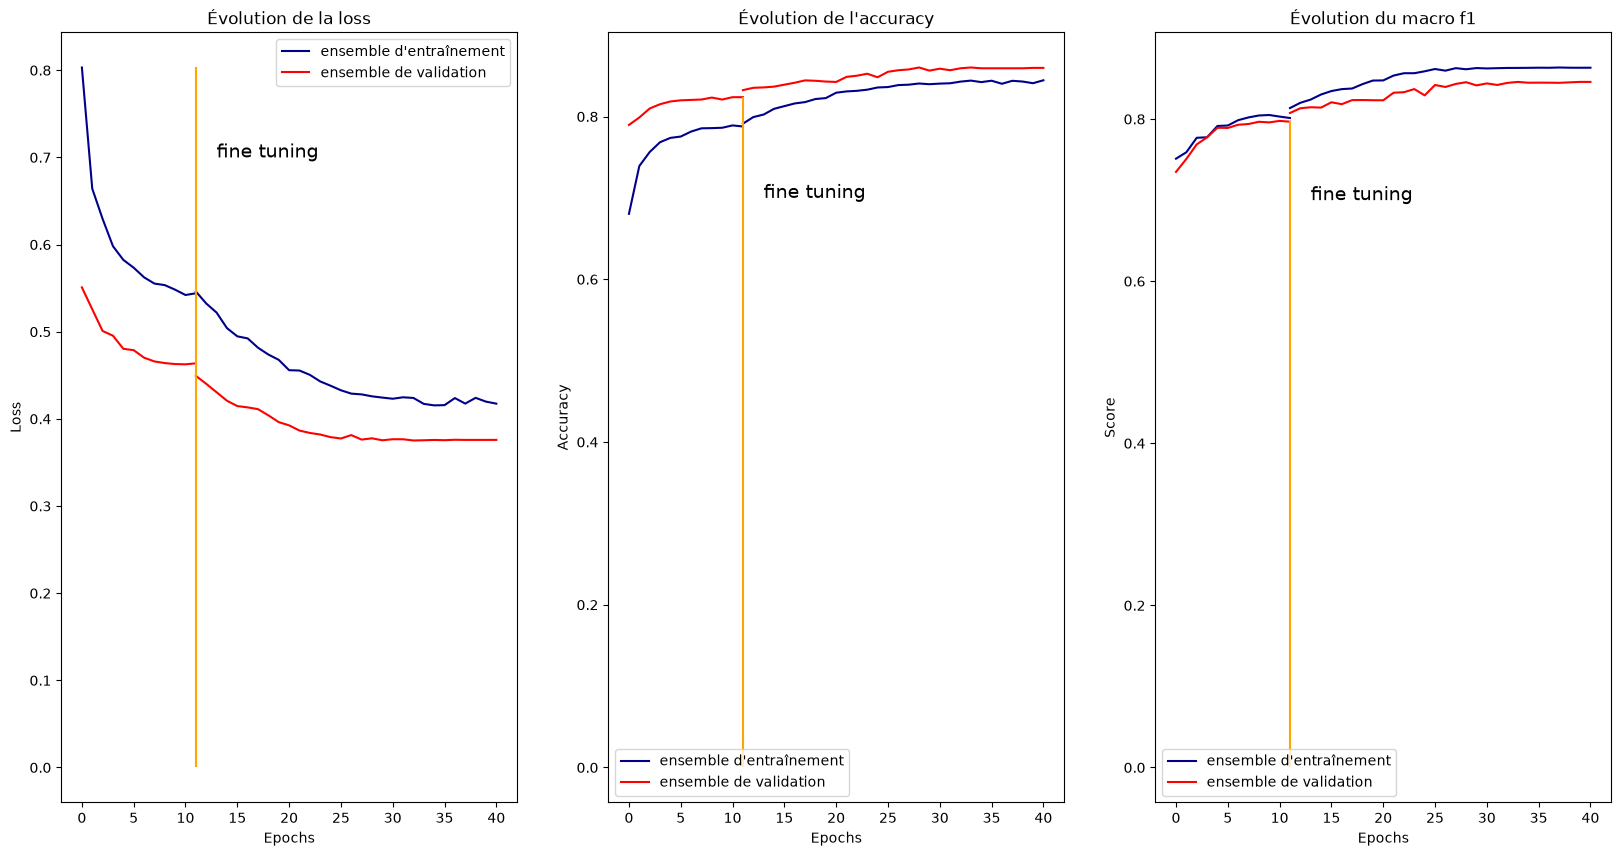

In [31]:
fig=plt.figure(figsize=(20,10))

plt.subplot(1,3,1)

plt.plot(np.arange(nb_epochs), train_loss, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_loss, color="red", label=["ensemble de validation"])
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, train_loss_fine, color="darkblue")
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, val_loss_fine, color="red")

plt.vlines(nb_epochs-1, 0, max(train_loss), color="orange")
plt.text(nb_epochs+1, 0.7, "fine tuning", fontsize=14)

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.title("Évolution de la loss")


plt.subplot(1,3,2)

plt.plot(np.arange(nb_epochs), train_acc, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_acc, color="red", label=["ensemble de validation"])
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, train_acc_fine, color="darkblue")
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, val_acc_fine, color="red")

plt.vlines(nb_epochs-1, 0, max(val_acc), color="orange")
plt.text(nb_epochs+1, 0.7, "fine tuning", fontsize=14)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.title("Évolution de l'accuracy")

plt.subplot(1,3,3)

plt.plot(np.arange(nb_epochs), train_f1, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_f1, color="red", label=["ensemble de validation"])
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, train_f1_fine, color="darkblue")
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, val_f1_fine, color="red")

plt.vlines(nb_epochs-1, 0, max(val_f1), color="orange")
plt.text(nb_epochs+1, 0.7, "fine tuning", fontsize=14)

plt.xlabel("Epochs")
plt.ylabel("Score")

plt.legend()

plt.title("Évolution du macro f1")

plt.show()

In [3]:
with open("history_FineTuned_EfficientNet.pkl", "wb") as f:
    pickle.dump(fine_tuned_history.history, f)

NameError: name 'pickle' is not defined

In [32]:
y_pred = model.predict(test_ds)
y_pred_class = y_pred.argmax(axis=1)

y_test_class = np.concatenate([labels for images,labels in test_ds] ,axis=0)
print(y_test_class)

print(classification_report(y_test_class, y_pred_class))

66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 292ms/step
[0 0 0 ... 3 3 3]
              precision    recall  f1-score   support

           0       0.84      0.71      0.77       337
           1       0.87      0.84      0.85       599
           2       0.87      0.94      0.91      1014
           3       0.98      0.94      0.96       134

    accuracy                           0.87      2084
   macro avg       0.89      0.86      0.87      2084
weighted avg       0.87      0.87      0.87      2084



[[238  39  60   0]
 [ 25 502  72   0]
 [ 21  34 956   3]
 [  1   1   6 126]]


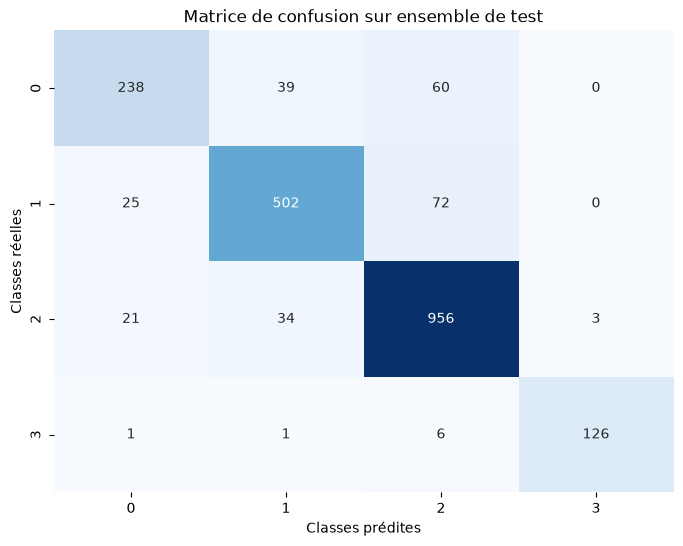

In [33]:
conf_matrix = confusion_matrix(y_test_class, y_pred_class)

print (conf_matrix)

plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de test")
sns.heatmap(conf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel("Classes réelles")
plt.xlabel("Classes prédites")
plt.show()

np.save("CM_FineTuned_EfficientNet.npy", conf_matrix)

9. Réentraînement du model avec class weight

In [40]:
#Calcul des poids

train_ds_not_augmented = image_dataset_from_directory(
    directory=chemin+"/train/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=True,
   color_mode='rgb' 
)


y_train_not_augmented = np.concatenate([labels for images, labels in train_ds_not_augmented], axis=0)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_not_augmented), y=y_train_not_augmented)
class_weight_dict = dict(enumerate(class_weights))

print(class_weight_dict)

Found 16668 files belonging to 4 classes.
{0: np.float64(1.544477390659748), 1: np.float64(0.8697557921102066), 2: np.float64(0.5138734739178691), 3: np.float64(3.894392523364486)}
